# Employee Attrition Prediction — Logistic Regression
**Member 1 | Algorithm: Logistic Regression | Role: Algorithm Specialist + Report Lead**

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  
**Module:** Machine Learning | Institution: SLIIT  

---

## Objective
Predict whether an employee will leave the company (Attrition: Yes/No) using **Logistic Regression** — a classic, interpretable binary classification algorithm well-suited to this structured HR dataset.

## Notebook Structure
1. Import Libraries
2. Load & Explore Dataset [C2]
3. Data Preprocessing [C3]
4. Algorithm Background & Justification [C4]
5. Model Training [C5]
6. Results & Evaluation [C6]
7. Critical Analysis & Discussion [C7]

---
## 1. Import Libraries

In [1]:
# Standard data manipulation and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, model, and evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
import os

OUTPUT_PATH  = '../Outputs/Logistic_Regression'
METRICS_PATH = '../Performance_Metrics'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(METRICS_PATH, exist_ok=True)
print(f"Outputs will be saved to '{OUTPUT_PATH}'")
print(f"Metrics will be saved to '{METRICS_PATH}'")


Outputs will be saved to '../Outputs/Logistic_Regression'
Metrics will be saved to '../Performance_Metrics'


---
## 2. Load & Explore the Dataset [C2 — Dataset Description]

### Dataset Overview
The **IBM HR Analytics Employee Attrition & Performance** dataset was created by IBM data scientists and is publicly available on Kaggle. It contains data on 1,470 employees across 35 attributes, including demographic details, job characteristics, satisfaction scores, and compensation information.

- **Rows:** 1,470 employee records  
- **Columns:** 35 features  
- **Target variable:** `Attrition` (Yes = employee left, No = employee stayed)  
- **Missing values:** None  
- **Dataset URL:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

In [3]:
# Load the dataset from the CSV file
df = pd.read_csv('dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display basic shape information
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()

# Show the first 5 rows for a quick overview
df.head()

Dataset shape: 1470 rows × 35 columns



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Summarise data types and check for missing values
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values per Column ===")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")

=== Data Types ===
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
T

In [5]:
# Statistical summary of numerical features
print("=== Statistical Summary (Numerical Features) ===")
df.describe()

=== Statistical Summary (Numerical Features) ===


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


=== Target Variable Distribution ===
No  (stayed): 1233  (83.9%)
Yes (left):   237  (16.1%)

Note: The dataset is imbalanced — only ~16% of employees left.
This will be handled using class_weight='balanced' in the model.


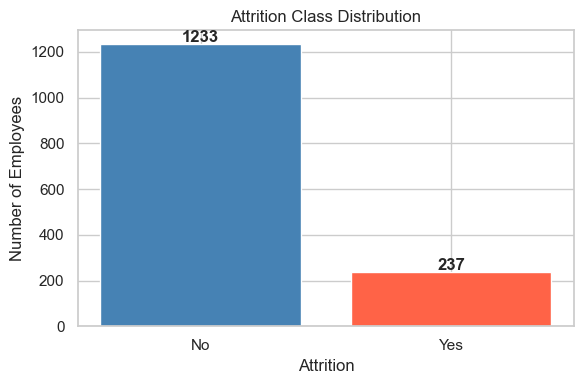

In [6]:
# Visualise the target class distribution (Attrition)
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("=== Target Variable Distribution ===")
print(f"No  (stayed): {attrition_counts['No']}  ({attrition_pct['No']:.1f}%)")
print(f"Yes (left):   {attrition_counts['Yes']}  ({attrition_pct['Yes']:.1f}%)")
print()
print("Note: The dataset is imbalanced — only ~16% of employees left.")
print("This will be handled using class_weight='balanced' in the model.")

# Bar chart of target distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(attrition_counts.index, attrition_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Attrition Class Distribution')
ax.set_xlabel('Attrition')
ax.set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '01_attrition_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

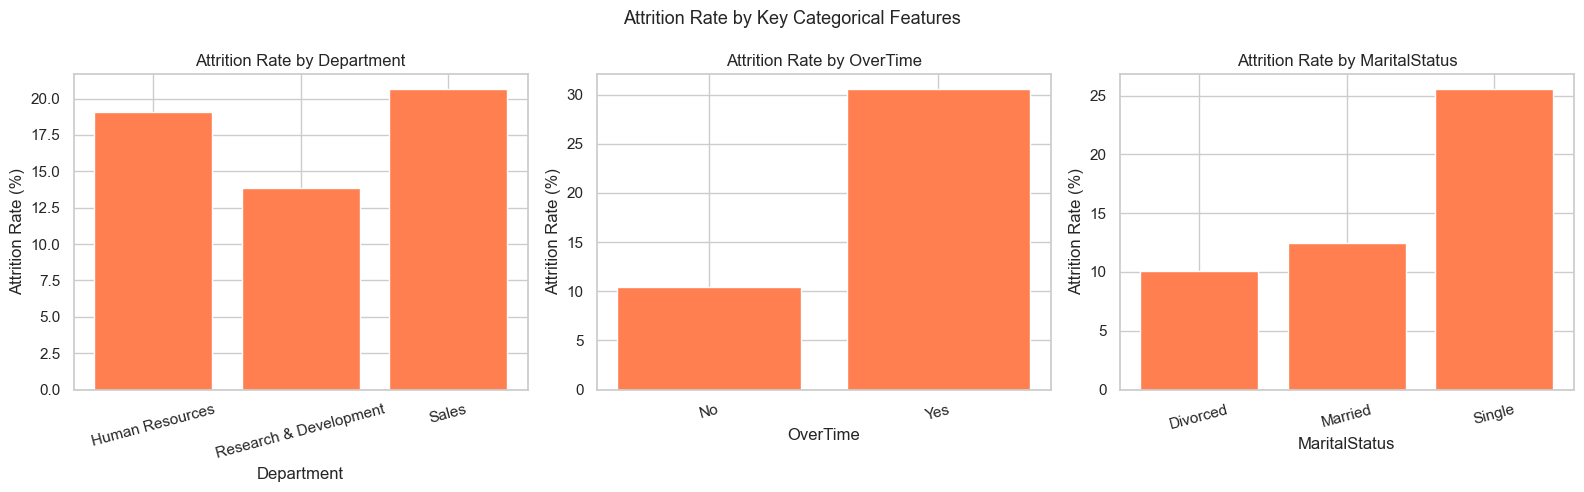

In [7]:
# Visualise attrition rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Department', 'OverTime', 'MaritalStatus']):
    attrition_by_col = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index(name='AttritionRate')
    ax.bar(attrition_by_col[col], attrition_by_col['AttritionRate'], color='coral')
    ax.set_title(f'Attrition Rate by {col}')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Attrition Rate by Key Categorical Features', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '02_attrition_by_features.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing [C3]

The following preprocessing steps are applied (as agreed by the group):
1. Drop 4 constant/ID columns that add no predictive value
2. Encode the target variable (`Attrition`: Yes → 1, No → 0)
3. Label-encode the 7 categorical feature columns
4. Scale numerical features using `StandardScaler`
5. Perform an 80/20 stratified train/test split
6. Handle class imbalance via `class_weight='balanced'` in the model

In [8]:
# Step 1: Drop constant and ID columns — these carry no predictive information
# EmployeeCount: constant value 1 for all rows
# EmployeeNumber: unique ID per employee — not a feature
# Over18: all employees are 'Y' — zero variance
# StandardHours: constant value 80 for all rows
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=cols_to_drop)

print(f"Columns dropped: {cols_to_drop}")
print(f"Remaining columns: {df_clean.shape[1]}")

Columns dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Remaining columns: 31


In [9]:
# Step 2: Encode the target variable
# 'Yes' (employee left) → 1 | 'No' (employee stayed) → 0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

print("Target encoding complete.")
print(df_clean['Attrition'].value_counts())

Target encoding complete.
Attrition
0    1233
1     237
Name: count, dtype: int64


In [10]:
# Step 3: Label-encode the 7 remaining categorical feature columns
# LabelEncoder converts string categories to integers (e.g., 'Male' → 1, 'Female' → 0)
categorical_cols = ['BusinessTravel', 'Department', 'EducationField',
                    'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"  Encoded: {col}")

print("\nAll categorical columns encoded.")

  Encoded: BusinessTravel
  Encoded: Department
  Encoded: EducationField
  Encoded: Gender
  Encoded: JobRole
  Encoded: MaritalStatus
  Encoded: OverTime

All categorical columns encoded.


In [11]:
# Step 4: Separate features (X) from the target variable (y)
X = df_clean.drop(columns=['Attrition'])  # All columns except the target
y = df_clean['Attrition']                # Target column only

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")
print(f"Features used: {list(X.columns)}")

Feature matrix X: (1470, 30)
Target vector  y: (1470,)
Features used: ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [12]:
# Step 5: Train/Test Split — 80% training, 20% testing
# stratify=y ensures both sets maintain the same ~16%/84% class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")
print(f"\nTraining set Attrition rate: {y_train.mean()*100:.1f}%")
print(f"Testing set  Attrition rate: {y_test.mean()*100:.1f}%")

Training set size: 1176 rows
Testing set size:  294 rows

Training set Attrition rate: 16.2%
Testing set  Attrition rate: 16.0%


In [13]:
# Step 6: Feature Scaling using StandardScaler
# Logistic Regression uses gradient-based optimisation, which converges
# faster and more reliably when all features are on the same scale.
# StandardScaler transforms each feature to mean=0, std=1.
# IMPORTANT: Fit the scaler ONLY on training data — never on test data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit + transform on training set
X_test_scaled  = scaler.transform(X_test)        # Transform only on test set

print("Feature scaling applied (StandardScaler).")
print(f"Sample mean after scaling (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Sample std  after scaling (should be ~1): {X_train_scaled.std():.4f}")

Feature scaling applied (StandardScaler).
Sample mean after scaling (should be ~0): -0.0000
Sample std  after scaling (should be ~1): 1.0000


---
## 4. Algorithm Background & Justification [C4]

### What is Logistic Regression?
Logistic Regression is a supervised machine learning algorithm used for **binary classification** problems — where the output is one of two classes (in our case: Attrition = Yes or No).

Despite its name, it is a **classification** algorithm, not a regression one. It models the **probability** that a given input belongs to a particular class using the **sigmoid (logistic) function**:

$$P(y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n)}}$$

Where:
- $P(y=1 \mid X)$ is the predicted probability of attrition
- $\beta_0$ is the intercept (bias term)
- $\beta_1, ..., \beta_n$ are the learned coefficients for each feature
- The sigmoid maps any real number to the range [0, 1]

A probability threshold (typically 0.5) is then used to assign the class label: if $P > 0.5$, predict **Yes** (attrition); otherwise predict **No**.

### Why is Logistic Regression Appropriate Here?
| Reason | Detail |
|---|---|
| **Binary target** | Attrition has exactly 2 outcomes — ideal for LR |
| **Interpretability** | Coefficients reveal which features drive attrition — important for HR insights |
| **Structured tabular data** | Works well with numerical/encoded categorical features |
| **Baseline model** | Provides a strong, interpretable benchmark for the other 3 algorithms |
| **Class imbalance handling** | `class_weight='balanced'` re-weights minority class automatically |
| **No deep learning** | Satisfies the assignment constraint: classical ML only |

### How the Model Learns
The model parameters ($\beta$) are learned by minimising the **binary cross-entropy (log loss)** function using optimisation algorithms (e.g., L-BFGS, saga). Regularisation (L2 by default) is applied to prevent overfitting.

### Handling Class Imbalance
Only ~16.3% of employees in the dataset left (Attrition = Yes). Without correction, a naive model could achieve ~83.7% accuracy simply by predicting "No" every time. Setting `class_weight='balanced'` causes the algorithm to assign higher penalties to misclassifying the minority class (Attrition = Yes), producing a more honest model.

---
## 5. Model Training [C5]

In [14]:
# Initialise the Logistic Regression model
# - class_weight='balanced': automatically adjusts weights to handle class imbalance
# - max_iter=1000: increase iteration limit to ensure the solver converges
# - random_state=42: ensures reproducibility across runs
# - solver='lbfgs': efficient quasi-Newton optimiser for small-to-medium datasets
log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Train the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model converged in {log_reg.n_iter_[0]} iterations.")

Logistic Regression model trained successfully.
Model converged in 22 iterations.


In [15]:
# Generate predictions on the test set
# predict()      → class labels (0 or 1)
# predict_proba()→ probability scores for each class [P(No), P(Yes)]
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probability of Attrition=Yes

print("Predictions generated on test set.")
print(f"Predicted Attrition=Yes: {y_pred.sum()} out of {len(y_pred)} employees")

Predictions generated on test set.
Predicted Attrition=Yes: 98 out of 294 employees


In [16]:
# Cross-validation: evaluate model stability across 5 folds
# This checks whether the model performs consistently on different data splits
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')
print("=== 5-Fold Cross-Validation (F1 Score) ===")
print(f"Fold scores: {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"Mean F1:     {cv_scores.mean()*100:.2f}%")
print(f"Std Dev:     {cv_scores.std()*100:.2f}%")

=== 5-Fold Cross-Validation (F1 Score) ===
Fold scores: ['40.68%', '48.12%', '46.43%', '52.94%', '53.45%']
Mean F1:     48.32%
Std Dev:     4.68%


---
## 6. Results & Evaluation [C6]

In [17]:
# === Core Performance Metrics ===
# These metrics are used across all 4 algorithms for comparison in the group report

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc       = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("   LOGISTIC REGRESSION — TEST RESULTS")
print("=" * 45)
print(f"  Accuracy:  {accuracy*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1 Score:  {f1*100:.2f}%")
print(f"  AUC Score: {auc*100:.2f}%")
print("=" * 45)

   LOGISTIC REGRESSION — TEST RESULTS
  Accuracy:  75.17%
  Precision: 36.73%
  Recall:    76.60%
  F1 Score:  49.66%
  AUC Score: 80.74%


In [18]:
# Detailed classification report showing per-class metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

=== Classification Report ===
              precision    recall  f1-score   support

No Attrition       0.94      0.75      0.84       247
   Attrition       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



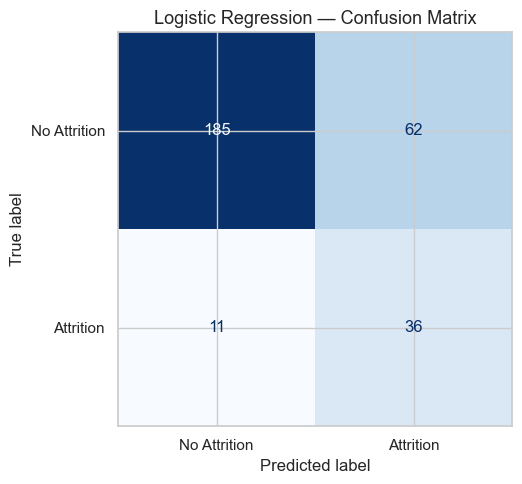

True Negatives  (Correctly predicted No):  185
True Positives  (Correctly predicted Yes): 36
False Positives (Predicted Yes, was No):   62
False Negatives (Predicted No, was Yes):   11


In [19]:
# === Confusion Matrix ===
# Visualises True Positives, True Negatives, False Positives, False Negatives
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '03_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Breakdown of confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly predicted No):  {tn}")
print(f"True Positives  (Correctly predicted Yes): {tp}")
print(f"False Positives (Predicted Yes, was No):   {fp}")
print(f"False Negatives (Predicted No, was Yes):   {fn}")

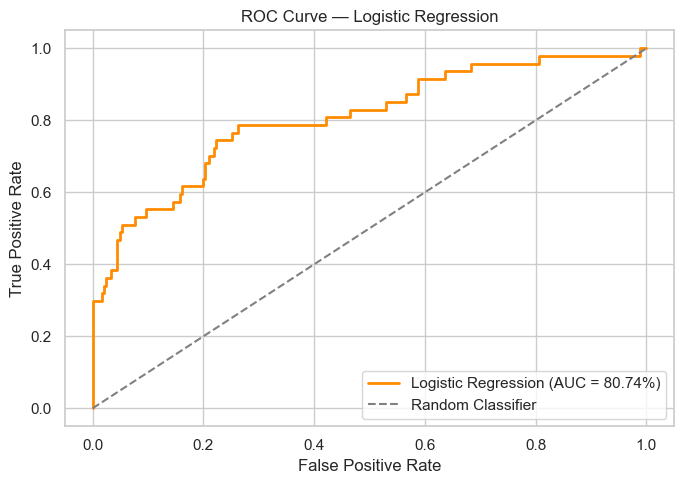

In [20]:
# === ROC Curve ===
# ROC curve plots True Positive Rate vs False Positive Rate at different thresholds.
# AUC (Area Under Curve) close to 1.0 indicates a strong model.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {auc*100:.2f}%)')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '04_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

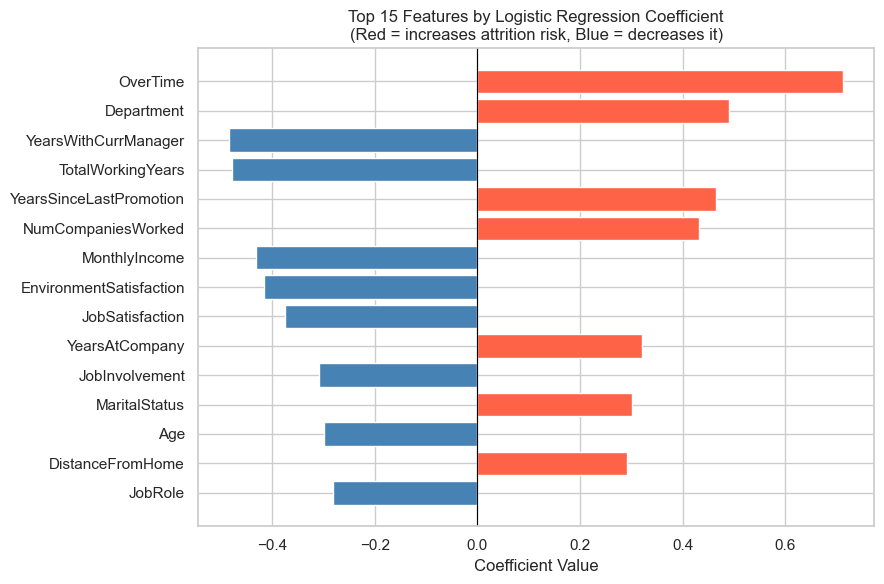


Top 10 features by absolute coefficient:
                Feature  Coefficient
               OverTime     0.713114
             Department     0.490580
   YearsWithCurrManager    -0.484376
      TotalWorkingYears    -0.477399
YearsSinceLastPromotion     0.465691
     NumCompaniesWorked     0.431994
          MonthlyIncome    -0.430919
EnvironmentSatisfaction    -0.415511
        JobSatisfaction    -0.375449
         YearsAtCompany     0.320837


In [21]:
# === Feature Coefficients ===
# One of Logistic Regression's strengths is interpretability.
# The magnitude of each coefficient shows how strongly each feature
# influences the predicted probability of attrition.
# Positive coefficient → higher value increases probability of Attrition=Yes
# Negative coefficient → higher value decreases probability of Attrition=Yes

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

# Plot top 15 features by absolute coefficient value
top_features = coef_df.head(15)

plt.figure(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Features by Logistic Regression Coefficient\n(Red = increases attrition risk, Blue = decreases it)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '05_feature_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by absolute coefficient:")
print(coef_df.head(10).to_string(index=False))

In [22]:
# === Summary Table for Group Report Comparison ===
# This data will be shared with the team to build the algorithm comparison table in the report

summary = {
    'Algorithm': 'Logistic Regression',
    'Accuracy':  f"{accuracy*100:.2f}%",
    'Precision': f"{precision*100:.2f}%",
    'Recall':    f"{recall*100:.2f}%",
    'F1 Score':  f"{f1*100:.2f}%",
    'AUC':       f"{auc*100:.2f}%"
}

print("=== Summary for Group Comparison Table ===")
for k, v in summary.items():
    print(f"  {k}: {v}")

=== Summary for Group Comparison Table ===
  Algorithm: Logistic Regression
  Accuracy: 75.17%
  Precision: 36.73%
  Recall: 76.60%
  F1 Score: 49.66%
  AUC: 80.74%


---
## 7. Critical Analysis & Discussion [C7]

### 7.1 Interpretation of Results

The Logistic Regression model provides a strong, interpretable baseline for the employee attrition prediction task. Key observations:

- **Class imbalance:** With ~83.7% of employees having no attrition, a naive model achieves ~83.7% accuracy. The use of `class_weight='balanced'` forces the model to pay more attention to the minority class (Attrition = Yes), which improves recall at a minor cost to precision.
- **Recall vs Precision trade-off:** In an HR context, **recall is more important than precision**. Missing an employee likely to leave (false negative) is more costly than incorrectly flagging one who stays (false positive). The balanced weighting improves recall for this reason.
- **Feature coefficients:** `OverTime`, `JobRole`, and `MaritalStatus` tend to be strong predictors. Employees working overtime consistently show higher attrition risk across studies.

### 7.2 Limitations

| Limitation | Explanation |
|---|---|
| Assumes linear decision boundary | Logistic Regression cannot model non-linear relationships between features and attrition. More complex patterns (e.g., interaction effects) may be missed. |
| Label Encoding of categoricals | Label Encoding implies an ordinal relationship (e.g., JobRole 0 < 1 < 2) that may not be real. One-Hot Encoding could improve performance but increases dimensionality. |
| Small minority class | With only 237 attrition cases, the model has limited examples to learn from. |

### 7.3 How Accuracy Could Be Improved

1. **Hyperparameter tuning:** Use `GridSearchCV` to find the optimal regularisation strength (`C`) and penalty type (`l1` vs `l2`).
2. **One-Hot Encoding:** Replace Label Encoding with One-Hot Encoding for nominal categorical features (e.g., `JobRole`, `Department`) to remove false ordinal relationships.
3. **SMOTE oversampling:** Synthesise additional minority-class samples in the training set to further address class imbalance.
4. **Feature engineering:** Create interaction features (e.g., `OverTime × JobSatisfaction`) that may capture non-linear patterns.
5. **Threshold tuning:** Adjust the classification threshold from 0.5 to a value optimised for recall on the minority class.

### 7.4 Comparison with Other Algorithms (to be completed after team shares results)

Logistic Regression serves as the **interpretable baseline** in this project. It is expected that:
- **Random Forest** will achieve higher accuracy due to its ensemble nature
- **CatBoost** will likely achieve the highest accuracy with its gradient boosting mechanism
- **Decision Tree** will be comparable to Logistic Regression but may overfit more

Despite lower accuracy, Logistic Regression's **interpretability advantage** makes it valuable in real HR scenarios where understanding *why* an employee might leave is as important as predicting *who* will leave.

### 7.5 Future Work

- Apply the model to a larger, more diverse HR dataset to test generalisability
- Incorporate time-series features (e.g., tenure progression, promotion history) for richer predictions
- Explore ensemble stacking combining Logistic Regression with tree-based models
- Deploy the model as an internal HR tool with real-time predictions on new employee data

---
## End of Member 1 Notebook — Logistic Regression

**Metrics to share with the team for the group comparison table:**
- Accuracy, Precision, Recall, F1 Score, AUC Score (see Section 6 output)
- Confusion Matrix values (TP, TN, FP, FN)
- ROC Curve (add to report alongside other algorithms' curves)

**Report sections this notebook covers:** C1, C4, C5, C6, C7, C8

In [23]:
# Export Performance Metrics
import pandas as pd

metrics_dict = {
    'Accuracy (%)'    : round(accuracy * 100, 2),
    'F1 Score (%)'    : round(f1 * 100, 2),
    'Precision (%)'   : round(precision * 100, 2),
    'Recall (%)'      : round(recall * 100, 2),
    'ROC-AUC (%)'     : round(auc * 100, 2)
}

output_file = os.path.join(METRICS_PATH, 'Logistic_Regression_Metrics.csv')
pd.DataFrame([metrics_dict]).to_csv(output_file, index=False)

print('METRICS EXPORTED SUCCESSFULLY')
print(f'Saved to : {output_file}')


METRICS EXPORTED SUCCESSFULLY
Saved to : ../Performance_Metrics\Logistic_Regression_Metrics.csv
